# Denoising Diffusion Implicit Models (DDIM)

In this tutorial, we will create and train an **unconditional** [Denoising Diffusion Implicit Models (DDIM)](https://arxiv.org/abs/2010.02502) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) API, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API. All experiments in this tutorial were run on a consumer laptop with an Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM). The code is designed to be lightweight so it can run on modest hardware, at the cost of longer training times and lower image resolution compared to large-scale DDPM setups. On GPUs with more memory, you can increase image resolution, model size, and batch size for better sample quality and faster convergence.

<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ddim.png" alt="UnCLIP overview" width="1200"/>
  <br>
  <em>An overview of the DDIM pipeline. Song, J., Meng, C., & Ermon, S. (2020).</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a DDIM Model](#training-a-ddim-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

For this tutorial, we will use the [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/).

In [1]:
# Import all necessary libraries and modules for training a DDPM model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision.io import read_image
from torchvision.transforms import Resize, CenterCrop
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import glob
# import required classes from the DDIM module of TorchDiff
import torchdiff
from torchdiff.ddim import SchedulerDDIM, ReverseDDIM, ForwardDDIM, TrainDDIM, SampleDDIM
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import DiffusionNetwork, Metrics, mse_loss

In [2]:
print(torchdiff.__version__) # latest version 28.Jan.2026

2.7.0


## Downloading the CIFAR10 Dataset from Torchvision

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # For RGB
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|██████████| 170M/170M [00:24<00:00, 6.94MB/s] 
/home/loqman/Downloads/projs/TorchDiff/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [19]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
#val_loader = DataLoader(test_subset, batch_size=10, shuffle=False) we do not need to evaluate model during training for efficency reasons!

### Visualizing Training Images

In this section, we will visualize a few images from the training subset.

In [5]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def denormalize(tensor):
    return tensor * 0.5 + 0.5

def visualize_cifar10_grid(dataloader, num_images=64):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            break
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    fig, axes = plt.subplots(8, 8, figsize=(6, 6))
    #fig.suptitle('CIFAR-10 Dataset Sample', fontsize=10, y=0.98)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)
                img = torch.clamp(img, 0, 1)
                
                # Display image
                axes[i, j].imshow(img)
                axes[i, j].set_title(cifar10_classes[all_labels[idx]], fontsize=8, pad=2)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    plt.subplots_adjust(wspace=0.1, hspace=0.2, top=0.96, bottom=0.02, left=0.02, right=0.98)
    plt.show()

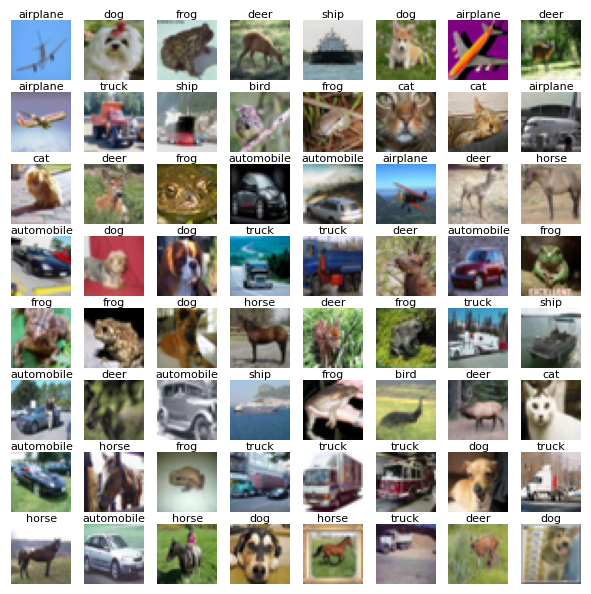

In [6]:
visualize_cifar10_grid(train_loader)

## Training Process of the DDIM Model

Before training a Denoising Diffusion Implicit Models (DDIM), we need to prepare several key components required for the training process:

- **DiffusionNetwork ([torchdiff.utils.DiffusionNetwork](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.DiffusionNetwork))**: this is the main network of all fundamental diffusion models (ddpm, ddim and sde) available in TorchDiff library, which is used as noise/score/v/x0 predictor.
 
- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  to train this model we will use adamw oprimizer from pytorch API.

- **Loss Function ([torchdiff.utils.mse_loss](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.mse_loss))**: a simple mean squared error loss implementation which is available in TorchDiff's utils module.

In [20]:
# Initialize the main model (which will be trained to predict noise in this case)
diff_net = DiffusionNetwork(
    in_channels = 3,  # 3 channels for RGB training data
    down_channels = [32, 64, 128, 256],
    mid_channels = [256, 256, 256], 
    up_channels = [256, 128, 64, 32],
    down_sampling = [True, True, True],
    time_embed_dim = 256,
    y_embed_dim = 256,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = False, # continuous time is used for SDE based model time sampling here no need to it
    use_flash_attention = True # if true automatically uses flash attention if available 
)

optim = torch.optim.AdamW(
    [p for p in diff_net.parameters()], lr=1e-4
)

In [21]:
print(sum(p.numel() for p in diff_net.parameters()))

11454403


### Required TorchDiff DDIM Classes for Training and Sampling

To train and sample from the DDIM model, we need the following specific components from ddim module of TrochDiff

- **DDIM Scheduler ([SchedulerDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.SchedulerDDIM))**:
  This class manages the noise schedule for the DDIM model.

- **Forward Diffusion ([ForwardDDIM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddim.ForwardDDPM))**: forward diffusion class of ddpm model applies forward ddim process and is used during training. 

- **Reverse Diffusion ([ReverseDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.ReverseDDIM))**:
  This class is used during the sampling process to perform reverse diffusion.

- **DDIM Trainer ([TrainDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.TrainDDIM))**:
  This class handles the training of the prepared DDIM model. For more details, refer to the [TorchDiff TrainDDIM documentation](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.TrainDDIM).

- **DDIM Sampler ([SampleDDIM](https://torchdiff.readthedocs.io/en/latest/ddpm.html#torchdiff.ddim.SampleDDIM))**:
  This class handles sampling process. it uses trained model and generates samples.

In [22]:
vs = SchedulerDDIM(
    schedule_type = "cosine", # linear variance calculation 
    train_steps = 1000,  # total timesteps for training
    sample_steps = 500,  # only 500 steps for sampling
)

fwd = ForwardDDIM(vs, pred_type = 'noise') # we will train an epsilon network (noise predictor)
rwd = ReverseDDIM(vs, pred_type = 'noise', eta = 0.0) # eta = 0 means deterministic sampling (ddim style), eta = 1.0 means stochastic sampling (ddpm style)

check = torch.load('best_model_epoch_50.pth', map_location='cuda')


# ddim trainer
trainer = TrainDDIM(
    diff_net = diff_net,
    fwd_ddim = fwd,
    rwd_ddim = rwd,
    train_loader = train_loader,
    optim = optim,
    loss_fn = mse_loss,
    val_loader = None, # for training efficiency no need to validate during training
    max_epochs = 50, # it should be enough 
    device = 'cuda',
    warmup_steps = 500, # set to zero after checkpointing
    grad_acc = 1, # gradient accumulation (over two steps)
    log_freq = 1,
    use_amp = False # use automatic mixed precision for faster training on supported GPUs
)

In [24]:
# start trining
# losses = trainer() # uncomment for training

In [26]:
c = torch.load('best_model_epoch_50.pth', map_location='cuda')

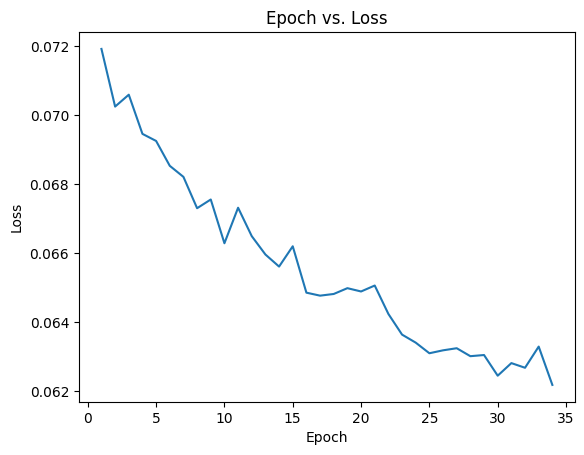

In [ ]:
plt.plot([i for i in range(1, 35)], c['losses']['train_losses'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling Process for the DDIM Model

After training is finished here we will generate multiple new images and see how well the trained model performs.

In [28]:
diff_net_ = DiffusionNetwork(
    in_channels = 3,
    down_channels = [32, 64, 128, 256],
    mid_channels = [256, 256, 256], 
    up_channels = [256, 128, 64, 32],
    down_sampling = [True, True, True],
    time_embed_dim = 256,
    y_embed_dim = 256,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = False, 
    use_flash_attention = True 
)

vs_ = SchedulerDDIM(
    schedule_type = "cosine", # linear variance calculation 
    train_steps = 1000,  # total timesteps for training
    sample_steps = 500,  # only 500 steps for sampling
)

rwd_ = ReverseDDIM(vs_, pred_type = 'noise', eta = 0.0)



# Load the trained parameters into the new NoisePredictor and set to evaluation mode
diff_net_.load_state_dict(check['model_state_dict_diff_net'])
diff_net_.eval()


rwd_.vs.load_state_dict(check['scheduler_model'])

<All keys matched successfully>

In [29]:
#vs_.sample_steps = 1000
sampler = SampleDDIM(
    rwd_ddim = rwd_,
    diff_net = diff_net_,
    img_size = (32, 32),
    batch_size = 100, # let's generate 100 images
    in_channels = 3,
    device = 'cuda'
)

In [ ]:
imgs = sampler(save_path = 'samples')

Sampling:   0%|          | 0/499 [00:00<?, ?it/s]

Sampling: 100%|██████████| 499/499 [00:43<00:00, 11.57it/s]


### Visualizing Generated Images

In [31]:
def denormalize(tensor):
    return tensor * 0.5 + 0.5

def visualize_(
    image_dir,
    num_images=64,
    image_size=32,
    normalize=True
):
    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ][:num_images]
    transform_list = [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ]
    if normalize:
        transform_list.append(
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        )
    transform = transforms.Compose(transform_list)
    images = []
    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        img = Image.open(img_path).convert("RGB")
        images.append(transform(img))

    images = torch.stack(images)
    fig, axes = plt.subplots(10, 10, figsize=(8, 8))
    for i in range(10):
        for j in range(10):
            idx = i * 10 + j
            axes[i, j].axis("off")

            if idx < len(images):
                img = images[idx]
                if normalize:
                    img = denormalize(img)
                img = img.permute(1, 2, 0)
                img = torch.clamp(img, 0, 1)
                axes[i, j].imshow(img)

    plt.subplots_adjust(
        wspace=0.05, hspace=0.05,
        top=0.98, bottom=0.02,
        left=0.02, right=0.98
    )
    plt.show()

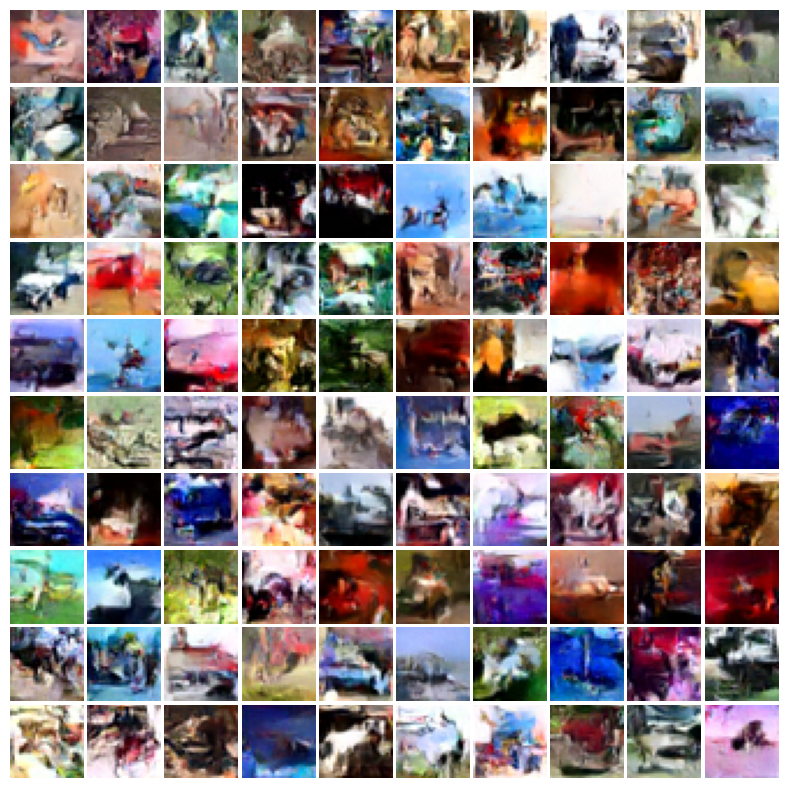

In [ ]:
visualize_(image_dir = "samples", num_images=100)

### Evaluating the Generated Images

The generated images are not as good as expected for multiple reasons: first, he model was trained for only 50 epochs, which may not be enough for the model to learn detailed features. second, the training process uses a basic (vanilla) algorithm, which may limit performance.

In addition, the loss function used is Mean Squared Error (MSE), which is not ideal for image generation and often leads to blurry results compared to more suitable losses such as DDIM-based losses.

You can download the trained model parameters and generated images here: [ddim](https://github.com/LoqmanSamani/TorchDiff/tree/systembiology/examples/ddim)

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)